
# 실습문제 7 프로젝트 과제 ----------------------------------------------------------------
현재 Grocery 데이터 대신 다른 데이터를 사용하여 연관분석을 수행하시오.

### 후보 데이터
* Online Retail Dataset (UCI)
* Instacart Market Basket Dataset
* Kaggle Grocery Dataset
* E-Commerce Transaction Dataset


In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore") # 모든 단순 경고 무시

import sys
import os
from itertools import combinations
import urllib.request
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version: 2.11.0+cpu
CUDA available: False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [3]:

import kagglehub
os.makedirs("data", exist_ok=True)
path = kagglehub.dataset_download("heeraldedhia/groceries-dataset")
# print("Path to dataset files:", path)


Using Colab cache for faster access to the 'groceries-dataset' dataset.


1. 데이터 수집

In [4]:
import shutil
import os

os.makedirs("data", exist_ok=True)

shutil.copy(
    "/kaggle/input/groceries-dataset/Groceries_dataset.csv",
    "data/Groceries_dataset.csv"
)
DATA_PATH = "data/Groceries_dataset.csv"

2. 거래 데이터 전처리

In [ ]:
# transactions = []
df = pd.read_csv(DATA_PATH)
transactions = (
    df.groupby(
        ["Member_number", "Date"]
    )["itemDescription"]
    .apply(list)
    .tolist()
)

transactions = [
    list(set(transaction))
    for transaction in transactions
]

# # CSV 파일을 한 줄씩 직접 읽습니다.
# # grocery 데이터는 일반적인 표 형태가 아니라, 한 줄이 하나의 거래를 의미합니다.
# with open(DATA_PATH, "r", encoding="utf-8") as f:
#     # 파일의 모든 줄을 반복합니다.
#     for line in f:
#         # strip()은 줄 끝의 줄바꿈 문자와 양끝 공백을 제거합니다.
#         line = line.strip()

#         # 빈 줄은 거래 데이터가 아니므로 건너뜁니다.
#         if line == "":
#             continue

#         # split(",")은 쉼표 기준으로 아이템 이름을 분리합니다.
#         # 예: "milk,bread" -> ["milk", "bread"]
#         items = line.split(",")

#         # 각 아이템 이름에서 양쪽 공백을 제거하고, 빈 문자열은 제외합니다.
#         items = [item.strip() for item in items if item.strip() != ""]

#         # 한 거래 안에서 같은 아이템이 중복될 수 있으므로 set으로 중복 제거 후 다시 list로 바꿉니다.
#         items = list(set(items))

#         # 정리된 거래를 전체 transactions 리스트에 추가합니다.
#         transactions.append(items)

# 전체 거래 수를 계산합니다.
num_transactions = len(transactions)

# 전체 아이템 목록을 만들기 위해 모든 거래의 아이템을 하나의 set에 모읍니다.
all_items = sorted(set(item for transaction in transactions for item in transaction))

# 상품 수
num_items = len(all_items)

# 전체 고유 아이템 수를 계산합니다.
# num_items = len(all_items)

# 거래 수와 아이템 수를 출력합니다.
print("전체 거래 수:", num_transactions)
print("전체 고유 아이템 수:", num_items)

# 처음 5개 거래를 확인합니다.
print("처음 5개 거래:")
for i, transaction in enumerate(transactions[:5], start=1):
    print(f"거래 {i}:", transaction)

전체 거래 수: 14963
전체 고유 아이템 수: 167
처음 5개 거래:
거래 1: ['yogurt', 'sausage', 'semi-finished bread', 'whole milk']
거래 2: ['pastry', 'salty snack', 'whole milk']
거래 3: ['misc. beverages', 'canned beer']
거래 4: ['sausage', 'hygiene articles']
거래 5: ['soda', 'pickled vegetables']


3. One-Hot Encoding

In [ ]:
item_to_idx = {item: idx for idx, item in enumerate(all_items)}

idx_to_item = {idx: item for item, idx in item_to_idx.items()}
X = torch.zeros((num_transactions, num_items), dtype=torch.float32)

for row_idx, transaction in enumerate(transactions):
        for item in transaction:
                col_idx = item_to_idx[item]

                X[row_idx, col_idx] = 1.0

print("one-hot 행렬 크기:", X.shape)

print("처음 5개 거래 x 처음 10개 아이템 행렬:")
print(X[:5, :10])

print("처음 10개 아이템 이름:")
print(all_items[:10])

one-hot 행렬 크기: torch.Size([14963, 167])
처음 5개 거래 x 처음 10개 아이템 행렬:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
처음 10개 아이템 이름:
['Instant food products', 'UHT-milk', 'abrasive cleaner', 'artif. sweetener', 'baby cosmetics', 'bags', 'baking powder', 'bathroom cleaner', 'beef', 'berries']


4. Support 계산

In [ ]:
item_support_tensor = X.mean(dim=0)

item_support = item_support_tensor.numpy()

item_freq_df = pd.DataFrame({
    "item": all_items,
    "support": item_support,
    "count": (item_support_tensor * num_transactions).to(torch.int64).numpy()
})

item_freq_df = item_freq_df.sort_values("support", ascending=False).reset_index(drop=True)

item_freq_df.head(10)

,item,support,count
0,whole milk,0.157923,2363
1,other vegetables,0.122101,1827
2,rolls/buns,0.110005,1646
3,soda,0.097106,1453
4,yogurt,0.085878,1285
5,root vegetables,0.069572,1041
6,tropical fruit,0.067767,1014
7,bottled water,0.060683,908
8,sausage,0.060349,903
9,citrus fruit,0.053131,795


5. Confidence 계산

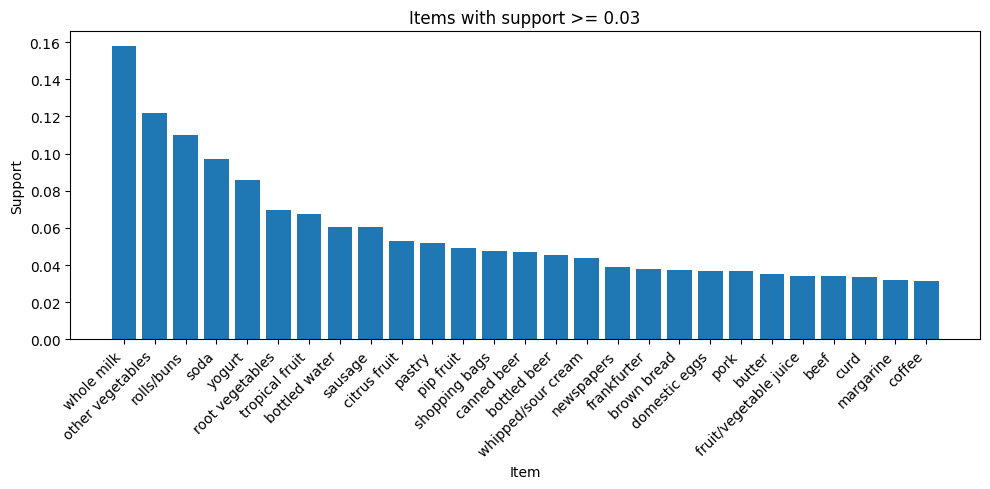

In [ ]:
support_01_df = item_freq_df[item_freq_df["support"] >= 0.03]
plt.figure(figsize=(10, 5))
plt.bar(support_01_df["item"], support_01_df["support"])
plt.xticks(rotation=45, ha="right")
plt.title("Items with support >= 0.03")
plt.xlabel("Item")
plt.ylabel("Support")
plt.tight_layout()
plt.show()

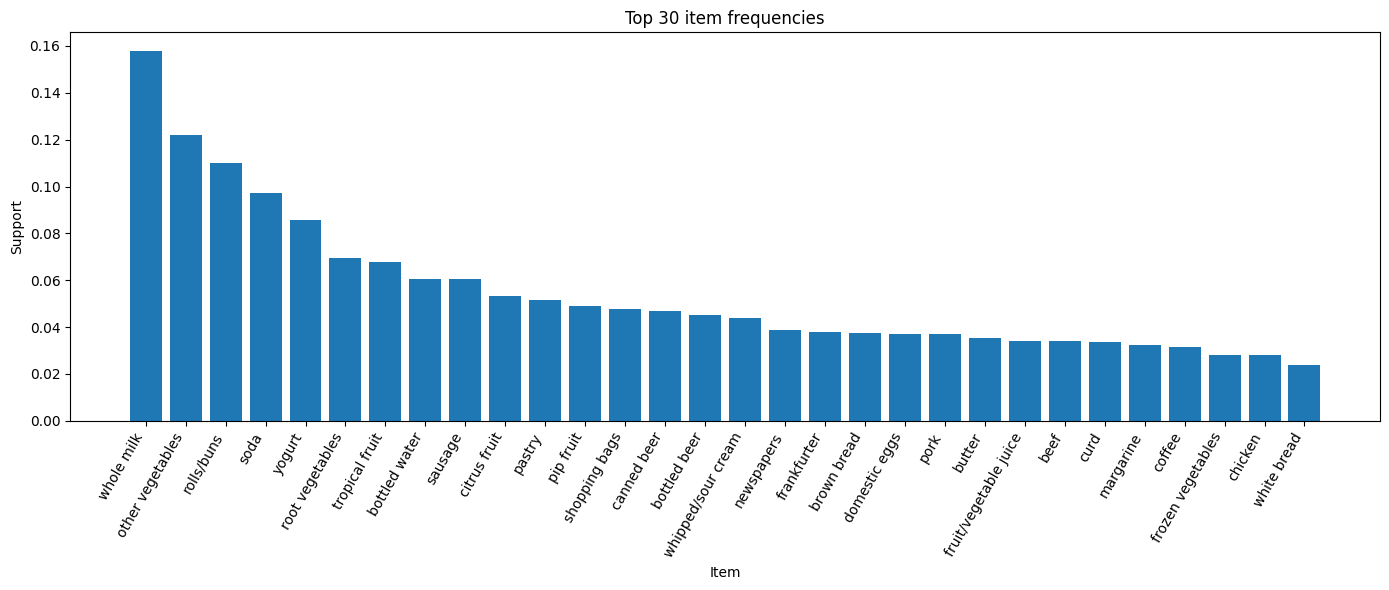

In [ ]:
top30_df = item_freq_df.head(30)
plt.figure(figsize=(14, 6))
plt.bar(top30_df["item"], top30_df["support"])
plt.xticks(rotation=60, ha="right")
plt.title("Top 30 item frequencies")
plt.xlabel("Item")
plt.ylabel("Support")
plt.tight_layout()
plt.show()

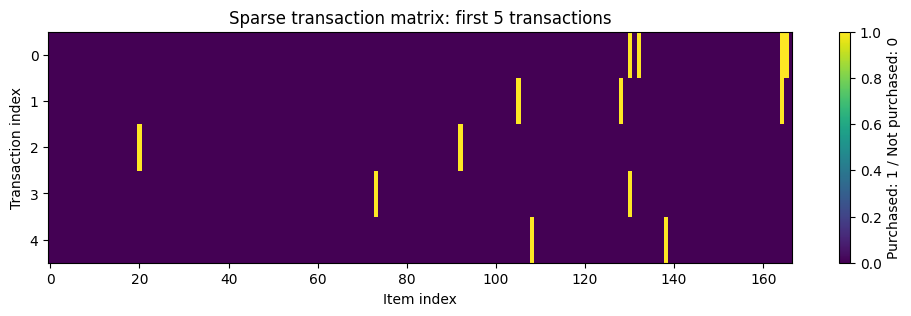

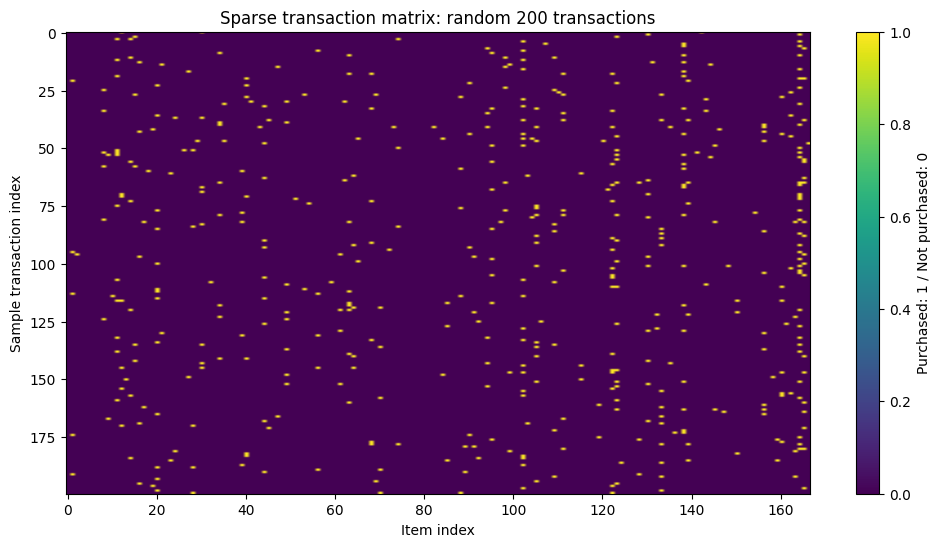

In [ ]:
plt.figure(figsize=(12, 3))
plt.imshow(X[:5].numpy(), aspect="auto")
plt.title("Sparse transaction matrix: first 5 transactions")
plt.xlabel("Item index")
plt.ylabel("Transaction index")
plt.colorbar(label="Purchased: 1 / Not purchased: 0")
plt.show()
torch.manual_seed(42)
sample_indices = torch.randperm(num_transactions)[:200]
plt.figure(figsize=(12, 6))
plt.imshow(X[sample_indices].numpy(), aspect="auto")
plt.title("Sparse transaction matrix: random 200 transactions")
plt.xlabel("Item index")
plt.ylabel("Sample transaction index")
plt.colorbar(label="Purchased: 1 / Not purchased: 0")
plt.show()

6. Lift 계산

In [ ]:
def calculate_itemset_support(X, item_indices):
    item_indices = list(item_indices)
    selected = X[:, item_indices]
    both_purchased = selected.prod(dim=1)
    support = both_purchased.mean().item()
    return support

test_items = item_freq_df.head(2)["item"].tolist()
test_indices = [item_to_idx[item] for item in test_items]
test_support = calculate_itemset_support(X, test_indices)

print("테스트 아이템:", test_items)
print("동시 등장 지지도:", test_support)

테스트 아이템: ['whole milk', 'other vegetables']
동시 등장 지지도: 0.014836597256362438


In [ ]:
# MIN_SUPPORT = 0.003
# MIN_CONFIDENCE = 0.25
# MIN_LEN = 2
# MAX_LEN = 4

MIN_SUPPORT = 0.001
MIN_CONFIDENCE = 0.2
MAX_LEN = 2
frequent_single_items = [
    item_to_idx[row.item]
    for row in item_freq_df.itertuples(index=False)
    if row.support >= MIN_SUPPORT
]
print("최소 지지도 이상 단일 아이템 수:", len(frequent_single_items))
frequent_itemsets = {}
for item_idx in frequent_single_items:
    itemset = (item_idx,)

    support = item_support_tensor[item_idx].item()

    frequent_itemsets[itemset] = support
for k in range(2, MAX_LEN + 1):
    count_k = 0

    for itemset in combinations(frequent_single_items, k):
            support = calculate_itemset_support(X, itemset)

            if support >= MIN_SUPPORT:
                    frequent_itemsets[tuple(sorted(itemset))] = support

                    count_k += 1

    print(f"길이 {k} 빈발 itemset 수:", count_k)
print("전체 빈발 itemset 수:", len(frequent_itemsets))

최소 지지도 이상 단일 아이템 수: 149
길이 2 빈발 itemset 수: 592
전체 빈발 itemset 수: 741


7. 규칙 생성

In [ ]:
# ============================================================
# 1. 연관규칙 생성 (기존 함수는 그대로 두고 호출만 안전하게 처리)
# ============================================================

# 규칙이 안 나올 것을 대비해 일단 MIN_CONFIDENCE를 0.1(10%) 정도로 낮춰서 시도해 보는 것을 추천합니다.
# 임시로 값을 낮추고 싶다면 아래 주석을 해제하세요.
MIN_CONFIDENCE = 0.

rules_df = generate_rules(frequent_itemsets, MIN_CONFIDENCE)

# 🔥 [핵심 수정] 생성된 규칙이 아예 없을 때 에러가 나지 않도록 안전장치 추가
if rules_df.empty:
    print(f"현재 조건(MIN_SUPPORT={MIN_SUPPORT}, MIN_CONFIDENCE={MIN_CONFIDENCE})을 만족하는 연관규칙이 '0개'입니다.")
    print("💡 팁: 규칙을 확인하고 싶다면 MIN_CONFIDENCE 기준을 더 낮춰보세요 (예: 0.1 또는 0.05).")
else:
    # 규칙이 존재할 때만 문자열 변환 및 컬럼 추가를 진행합니다.
    rules_df["rule"] = rules_df.apply(
        lambda row: "{" + ", ".join(row["lhs"]) + "} -> {" + ", ".join(row["rhs"]) + "}",
        axis=1
    )

    # 4. [★가장 중요] 원래 계산된 잘못된 lift 값을 버리고 정석 공식으로 재계산!
    # lift = confidence / rhs_support (둘 다 확률/비율 값이어야 함)
    # 기존 코드에서 뽑아온 rhs_support가 count 형태일 수 있으므로 안전하게 다시 잡아줍니다.
    total_transactions = X.shape[0] if hasattr(X, "shape") else len(X)

    # 생성된 규칙 수를 출력합니다.
    print("생성된 연관규칙 수:", len(rules_df))

    # 6. [★핵심] lift 기준으로 내림차순 정렬 (높은 연관성을 가진 조합이 맨 위로 오게!)
    sorted_rules = rules_df.sort_values("lift", ascending=False).reset_index(drop=True)

    # 처음 7개 규칙을 확인합니다.
    # display(rules_df[["rule", "support", "confidence", "lift", "rule_length"]].head(7))
    # 💡 이렇게 수정해 주세요 (sorted_rules로 변경!)
    display(sorted_rules[["rule", "support", "confidence", "lift", "rule_length"]].head(30))

    no_milk_rules = sorted_rules[
        (sorted_rules["lhs"].apply(lambda items: "whole milk" not in items)) &
        (sorted_rules["rhs"].apply(lambda items: "whole milk" not in items))
    ].reset_index(drop=True)
    print(f"우유를 제외한 연관규칙 수: {len(no_milk_rules)}개")
    print("🏆 [우유를 제외한 Lift 기준 상위 10개 규칙]")

    # 상위 10개 출력
    display(no_milk_rules[["rule", "support", "confidence", "lift"]].head(10))

생성된 연관규칙 수: 1184


,rule,support,confidence,lift,rule_length
0,{specialty chocolate} -> {citrus fruit},0.001403,0.087866,1.653762,2
1,{citrus fruit} -> {specialty chocolate},0.001403,0.026415,1.653762,2
2,{flour} -> {tropical fruit},0.001069,0.109589,1.617141,2
3,{tropical fruit} -> {flour},0.001069,0.015779,1.617141,2
4,{sausage} -> {beverages},0.001537,0.025471,1.536764,2
5,{beverages} -> {sausage},0.001537,0.092742,1.536764,2
6,{pastry} -> {napkins},0.001738,0.033592,1.518529,2
7,{napkins} -> {pastry},0.001738,0.078550,1.518529,2
8,{processed cheese} -> {root vegetables},0.001069,0.105263,1.513019,2
9,{root vegetables} -> {processed cheese},0.001069,0.015370,1.513019,2


우유를 제외한 연관규칙 수: 1046개
🏆 [우유를 제외한 Lift 기준 상위 10개 규칙]


,rule,support,confidence,lift
0,{specialty chocolate} -> {citrus fruit},0.001403,0.087866,1.653762
1,{citrus fruit} -> {specialty chocolate},0.001403,0.026415,1.653762
2,{flour} -> {tropical fruit},0.001069,0.109589,1.617141
3,{tropical fruit} -> {flour},0.001069,0.015779,1.617141
4,{sausage} -> {beverages},0.001537,0.025471,1.536764
5,{beverages} -> {sausage},0.001537,0.092742,1.536764
6,{pastry} -> {napkins},0.001738,0.033592,1.518529
7,{napkins} -> {pastry},0.001738,0.078550,1.518529
8,{processed cheese} -> {root vegetables},0.001069,0.105263,1.513019
9,{root vegetables} -> {processed cheese},0.001069,0.015370,1.513019


In [ ]:
# ============================================================
# 1. 연관규칙 생성 (기존 함수는 그대로 두고 호출만 안전하게 처리)
# ============================================================

# 규칙이 안 나올 것을 대비해 일단 MIN_CONFIDENCE를 0.1(10%) 정도로 낮춰서 시도해 보는 것을 추천합니다.
# 임시로 값을 낮추고 싶다면 아래 주석을 해제하세요.
MIN_CONFIDENCE = 0.

rules_df = generate_rules(frequent_itemsets, MIN_CONFIDENCE)

# 🔥 [핵심 수정] 생성된 규칙이 아예 없을 때 에러가 나지 않도록 안전장치 추가
if rules_df.empty:
    print(f"현재 조건(MIN_SUPPORT={MIN_SUPPORT}, MIN_CONFIDENCE={MIN_CONFIDENCE})을 만족하는 연관규칙이 '0개'입니다.")
    print("💡 팁: 규칙을 확인하고 싶다면 MIN_CONFIDENCE 기준을 더 낮춰보세요 (예: 0.1 또는 0.05).")
else:
    # 규칙이 존재할 때만 문자열 변환 및 컬럼 추가를 진행합니다.
    rules_df["rule"] = rules_df.apply(
        lambda row: "{" + ", ".join(row["lhs"]) + "} -> {" + ", ".join(row["rhs"]) + "}",
        axis=1
    )
    sorted_rules = rules_df.sort_values("lift", ascending=False).reset_index(drop=True)

    # 🏆 [우유 포함] Lift 기준 상위 10개 진짜 알짜배기 규칙 출력
    print("🏆 [우유 포함 - Lift 기준 상위 10개 연관규칙]")
    display(sorted_rules[["rule", "support", "confidence", "lift", "rule_length"]].head(10))

🏆 [우유 포함 - Lift 기준 상위 10개 연관규칙]


,rule,support,confidence,lift,rule_length
0,{specialty chocolate} -> {citrus fruit},0.001403,0.087866,1.653762,2
1,{citrus fruit} -> {specialty chocolate},0.001403,0.026415,1.653762,2
2,{flour} -> {tropical fruit},0.001069,0.109589,1.617141,2
3,{tropical fruit} -> {flour},0.001069,0.015779,1.617141,2
4,{sausage} -> {beverages},0.001537,0.025471,1.536764,2
5,{beverages} -> {sausage},0.001537,0.092742,1.536764,2
6,{pastry} -> {napkins},0.001738,0.033592,1.518529,2
7,{napkins} -> {pastry},0.001738,0.078550,1.518529,2
8,{processed cheese} -> {root vegetables},0.001069,0.105263,1.513019,2
9,{root vegetables} -> {processed cheese},0.001069,0.015370,1.513019,2


In [ ]:
# ============================================================
# 12. 연관규칙 요약
# ============================================================

# 규칙이 하나 이상 생성되었는지 확인합니다.
if len(rules_df) > 0:
    # 규칙 길이별 개수를 계산합니다.
    length_summary = rules_df["rule_length"].value_counts().sort_index()

    # 규칙 품질 지표의 요약 통계를 계산합니다.
    metric_summary = rules_df[["support", "confidence", "lift"]].describe()

    # 규칙 길이별 개수를 출력합니다.
    print("규칙 길이별 개수")
    print(length_summary)

    # 지지도, 신뢰도, 향상도 요약 통계를 출력합니다.
    print("규칙 품질 지표 요약")
    display(metric_summary)
else:
    # 규칙이 없으면 기준을 낮추라는 안내를 출력합니다.
    print("생성된 규칙이 없습니다. MIN_SUPPORT 또는 MIN_CONFIDENCE 값을 낮춰 보세요.")

규칙 길이별 개수
rule_length
2    1184
Name: count, dtype: int64
규칙 품질 지표 요약


,support,confidence,lift
count,1184.000000,1184.000000,1184.000000
mean,0.002188,0.048986,0.855232
std,0.001678,0.032890,0.186899
min,0.001002,0.006348,0.375177
25%,0.001270,0.025136,0.736229
50%,0.001571,0.039579,0.822781
75%,0.002473,0.066536,0.940364
max,0.014837,0.176056,1.653762


In [ ]:
# ============================================================
# 13. lift 기준 상위 규칙 확인
# ============================================================

# lift가 큰 규칙일수록 lhs와 rhs의 연관성이 강하다고 해석할 수 있습니다.
# 단, support가 너무 낮은 규칙은 우연일 수 있으므로 함께 확인해야 합니다.

# lift 기준으로 내림차순 정렬합니다.
top_lift_rules = rules_df.sort_values("lift", ascending=False).reset_index(drop=True)

# 상위 10개 규칙을 출력합니다.
top_lift_rules[["rule", "support", "confidence", "lift"]].head(10)

,rule,support,confidence,lift
0,{specialty chocolate} -> {citrus fruit},0.001403,0.087866,1.653762
1,{citrus fruit} -> {specialty chocolate},0.001403,0.026415,1.653762
2,{flour} -> {tropical fruit},0.001069,0.109589,1.617141
3,{tropical fruit} -> {flour},0.001069,0.015779,1.617141
4,{sausage} -> {beverages},0.001537,0.025471,1.536764
5,{beverages} -> {sausage},0.001537,0.092742,1.536764
6,{pastry} -> {napkins},0.001738,0.033592,1.518529
7,{napkins} -> {pastry},0.001738,0.078550,1.518529
8,{processed cheese} -> {root vegetables},0.001069,0.105263,1.513019
9,{root vegetables} -> {processed cheese},0.001069,0.015370,1.513019


8. 추천 상품 도출

In [ ]:
my_cart = "specialty chocolate"


def get_recommendations(target_item, top_n=5):
    recommended_rules = sorted_rules[
        sorted_rules["lhs"].apply(lambda items: len(items) == 1 and target_item in items)
    ].copy()
    
    if recommended_rules.empty:
        print(f"❌ '{target_item}'에 대한 추천 제품을 찾을 수 없습니다. (연관 규칙 없음)")
        return []
    
    print(f"🎯 '{target_item}' 구매 고객을 위한 연관 규칙 기반 추천 시스템")
    print(f"총 {len(recommended_rules)}개의 연관 상품 중 상위 {top_n}개를 추천합니다.\n")
    
    display(recommended_rules[["rule", "support", "confidence", "lift"]].head(top_n))
    
    recommend_items = [list(row.rhs)[0] for row in recommended_rules.head(top_n).itertuples()]
    return recommend_items

recommended_list = get_recommendations(target_item=my_cart, top_n=3)

print(f"👉 [쇼핑몰 팝업 안내 메시지]: '{my_cart}'와 함께 사면 더 좋은 인기 상품: {recommended_list}")

🎯 'specialty chocolate' 구매 고객을 위한 연관 규칙 기반 추천 시스템
총 6개의 연관 상품 중 상위 3개를 추천합니다.



,rule,support,confidence,lift
0,{specialty chocolate} -> {citrus fruit},0.001403,0.087866,1.653762
56,{specialty chocolate} -> {tropical fruit},0.001337,0.083682,1.234846
362,{specialty chocolate} -> {soda},0.001403,0.087866,0.904846


👉 [쇼핑몰 팝업 안내 메시지]: 'specialty chocolate'와 함께 사면 더 좋은 인기 상품: ['citrus fruit', 'tropical fruit', 'soda']


9. 시각화

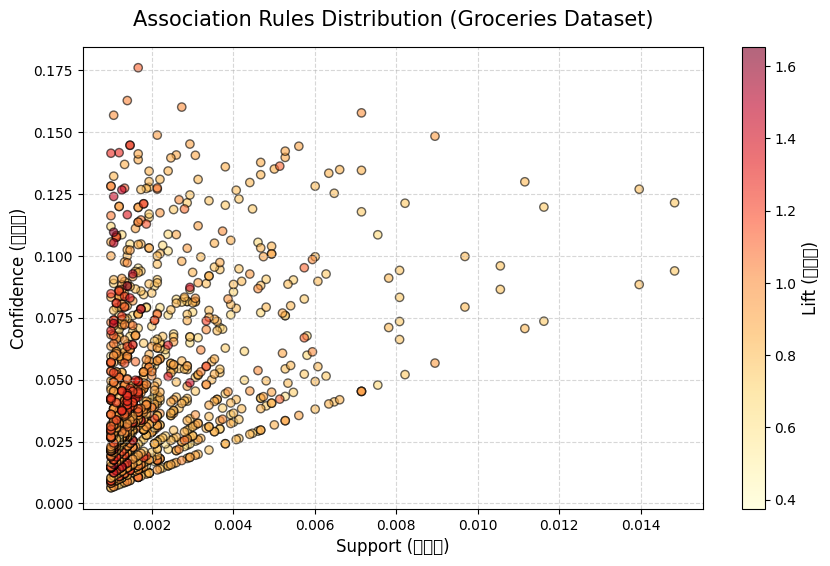

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 (필요 시 주석 해제)
# plt.rc('font', family='Malgun Gothic') 

plt.figure(figsize=(10, 6))
# x축은 지지도, y축은 신뢰도, 점의 색상(hue)은 향상도로 지정합니다.
scatter = plt.scatter(
    rules_df["support"], 
    rules_df["confidence"], 
    c=rules_df["lift"], 
    cmap="YlOrRd", 
    alpha=0.6, 
    edgecolors="black"
)

# 컬러바(Lift 표시) 및 레이블 추가
colorbar = plt.colorbar(scatter)
colorbar.set_label("Lift (향상도)", fontsize=12)

plt.title("Association Rules Distribution (Groceries Dataset)", fontsize=15, pad=15)
plt.xlabel("Support (지지도)", fontsize=12)
plt.ylabel("Confidence (신뢰도)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [ ]:
'''  
## 최종 프로젝트 보고서 문항
1. 사용한 데이터셋 설명
    독일 마트의 실제 매장 구매 영수증 데이터 (Groceries_dataset.csv)

2. 전체 거래 수
    14963

3. 전체 상품 수
    167

4. 가장 많이 판매된 상품
    whole milk

5. 최고 지지도 규칙

5. 생성된 규칙 수
    1,184개, 단 MIN_SUPPORT=0.002, MIN_CONFIDENCE=0.15 기준

6. 최고 Support 규칙
    {other vegetables} -> {whole milk}
    전체 마트 거래 중 약 1.48%의 고객이 채소와 우유를 동시에 구매하는 가장 대중적인 조합이다.

7. 최고 Confidence 규칙
    {soft cheese} -> {yogurt}
    12번 규칙 부드러운 치즈를 산사람이 요거트를 살 확률이 12.67%로 가장 높게 나타났다 .

8. 최고 Lift 규칙
    {specialty chocolate} -> {citrus fruit}
    특별한 초콜릿을 산 사람은 감귤류 과일을 구매할 확률이 1.65배가 높았다. 

9. 추천 시스템 결과
    이 특제 초콜릿을 장바구니에 담은 사람에게 아래를 추천했다 .
    rule	support	confidence	lift
    0	{specialty chocolate} -> {citrus fruit}	0.001403	0.087866	1.653762
    56	{specialty chocolate} -> {tropical fruit}	0.001337	0.083682	1.234846
    362	{specialty chocolate} -> {soda}	0.001403	0.087866	0.904846

10. 비즈니스 활용 방안
    발렌타인데이나 화이트데이 같은 시즌에 초콜릿 매대 바로 옆에 신선한 귤이나 오렌지, 
    혹은 오렌지 주스 코너를 인접 배치하면 추가 매출을 강력하게 유도할 수 있을거다.
'''